### L1L2Mix model training

Let's train a model using our baseline setup *with L1L2Mix regulization*. My network contains 3 hidden layers and 128 hidden units with ReLU activation function. I use the Adam optimiser with a learning rate of 10−4.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.train_model_and_plot_stats import train_model_and_plot_stats
from mlp.penalties import L1L2MixPenalty

In [2]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=False)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=False)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [3]:
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

In [4]:
# Create model with three hidden layers and L1 penalties on weights and biases

# lambda = decay coefficient
lamda = [5e-4, 5e-4, 5e-4, 1e-3]

# alpha = mixing term between L1 and L2
alpha = [0.25, 0.50, 0.75, 0.25]

stats_all_runs = {}

for i in range(len(lamda)):
  print(f"Run {i+1} - lambda: {lamda[i]}, alpha: {alpha[i]}")
  weights_init = GlorotUniformInit(rng=rng)
  biases_init = ConstantInit(0.)
  error =  CrossEntropySoftmaxError()
  # Use a Adam learning rule
  learning_rule = AdamLearningRule(learning_rate=learning_rate)
  model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])) # output layer
  ])

  # stats, keys, run_time, fig_1, ax_1, fig_2ç, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
  #     model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
  # stats_all_runs[i] = stats



Run 1 - lambda: 0.0005, alpha: 0.25
Run 2 - lambda: 0.0005, alpha: 0.5
Run 3 - lambda: 0.0005, alpha: 0.75
Run 4 - lambda: 0.001, alpha: 0.25


In [10]:
# get all stats from run
import pickle
with open('/Users/hallaei/UoE/mlp/mlpractical/data/emnist_l1l2_mixing_stats.pkl', 'rb') as f:
    stats_all_runs = pickle.load(f)

# Get final val_acc train_error and val_error for each run
final_stats = []
for i in range(len(stats_all_runs)):
    stats = stats_all_runs[i][-1]
    val_acc = stats[3]
    train_err = stats[0]
    val_err = stats[2]
    final_stats.append( (val_acc, train_err, val_err))

# Print final stats in a table
print(f"{'Run':<5} {'Val Accuracy':<15} {'Train Error':<15} {'Val Error':<15}")
for i, (val_acc, train_err, val_err) in enumerate(final_stats):
    print(f"{i+1:<5}{val_acc:<15.4f} {train_err:<15.4f} {val_err:<15.4f}")

Run   Val Accuracy    Train Error     Val Error      
1    0.8435          0.4372          0.4775         
2    0.8294          0.5059          0.5322         
3    0.8126          0.5865          0.6096         
4    0.8211          0.5379          0.5628         


In [11]:
### Plotting gap and validation accuracies for my experiments
# lambda = decay coefficient
lamda = [5e-4, 5e-4, 5e-4, 1e-3]

# alpha = mixing term between L1 and L2
alpha = [0.25, 0.50, 0.75, 0.25]

# Create dataset of (lamda,alpha), val_acc, train_err, val_err
L1L2Mix_data = []
for i in range(len(stats_all_runs)):
    stats = stats_all_runs[i][-1]
    val_acc = stats[3]
    train_err = stats[0]
    val_err = stats[2]
    L1L2Mix_data.append((lamda[i], alpha[i], val_acc, train_err, val_err) )

L1L2Mix_data= np.array(L1L2Mix_data)

L1L2Mix_data

array([[5.00000000e-04, 2.50000000e-01, 8.43481013e-01, 4.37221677e-01,
        4.77542231e-01],
       [5.00000000e-04, 5.00000000e-01, 8.29367089e-01, 5.05853171e-01,
        5.32192260e-01],
       [5.00000000e-04, 7.50000000e-01, 8.12594937e-01, 5.86453399e-01,
        6.09620332e-01],
       [1.00000000e-03, 2.50000000e-01, 8.21139241e-01, 5.37886763e-01,
        5.62838991e-01]])

In [12]:
# Calculate error gap
error_gap = L1L2Mix_data[:,4] - L1L2Mix_data[:,3]
L1L2Mix_data = np.column_stack((L1L2Mix_data, error_gap))

Lamdbda values:
[0.0005 0.001 ]
Validation Accuracies:
[0.84348101 0.82113924]
Generalisation Gaps:
[0.04032055 0.02495223]


/var/folders/xr/33dl1gs96gld0804tl6dsvxw0000gn/T/ipykernel_22926/2581061414.py:34: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax_mix_left.legend(lines, labels, loc=0)


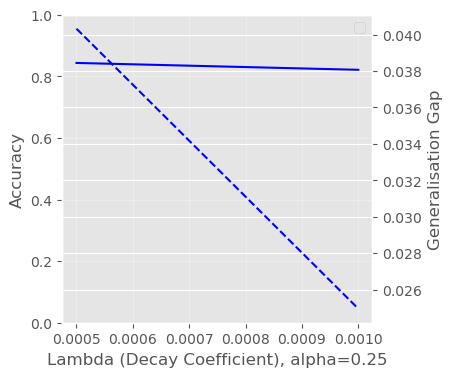

In [ ]:
# Plotting the Validation Accuracy and Generalisation Gap (difference between validation and training error) for each of the experiment results varying the hyperparameter combo

mix_plot = plt.figure(figsize=(4,4))
ax_mix_left = mix_plot.add_subplot(111)
ax_mix_right = ax_mix_left.twinx()

# Use only lamda values where alpha=0.25
mask = L1L2Mix_data[:,1] == 0.25
L1L2Mix_data = L1L2Mix_data[mask]

print("Lamdbda values:")
print(L1L2Mix_data[:,0])

print("Validation Accuracies:")
print(L1L2Mix_data[:,2])

print("Generalisation Gaps:")
print(L1L2Mix_data[:,5])

# For lamda
line_acc_lamda = ax_mix_left.plot(L1L2Mix_data[:,0], L1L2Mix_data[:,2], label='Val. Acc.', color='blue')
line_gap_lamda = ax_mix_right.plot(L1L2Mix_data[:,0], L1L2Mix_data[:,5], label='Gap', linestyle='dashed', color='blue')

# ax_mix_left.legend(loc=0)
ax_mix_left.set_xlabel(r'$\lambda$ (Decay Coefficient), $\alpha$=0.25')
ax_mix_left.set_ylabel('Accuracy')
ax_mix_left.set_ylim(0.0, 1.0)


ax_mix_right.set_ylabel('Generalisation Gap')

lines = [line_acc_lamda, line_gap_lamda]
labels = [l[0].get_label() for l in lines]
ax_mix_left.legend(lines, labels, loc=0)
ax_mix_left.grid(True, alpha=0.3)


mix_plot.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/mix_wd_lambda_plot.png')


Alpha values:
[0.25 0.5  0.75]
Validation Accuracies:
[0.84348101 0.82936709 0.81259494]
Generalisation Gaps:
[0.04032055 0.02633909 0.02316693]


/var/folders/xr/33dl1gs96gld0804tl6dsvxw0000gn/T/ipykernel_22926/3651104702.py:34: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax_mix_left.legend(lines, labels, loc=0)


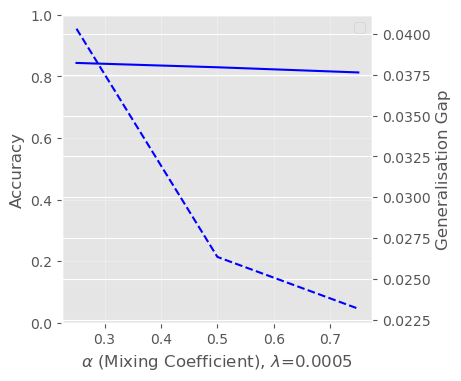

In [14]:
# Plotting the Validation Accuracy and Generalisation Gap (difference between validation and training error) for each of the experiment results varying the hyperparameter combo

mix_plot = plt.figure(figsize=(4,4))
ax_mix_left = mix_plot.add_subplot(111)
ax_mix_right = ax_mix_left.twinx()

# Use only lamda values where lambda=0.0005
mask = L1L2Mix_data[:,0] == 5e-4
L1L2Mix_data = L1L2Mix_data[mask]

print("Alpha values:")
print(L1L2Mix_data[:,1])

print("Validation Accuracies:")
print(L1L2Mix_data[:,2])

print("Generalisation Gaps:")
print(L1L2Mix_data[:,5])

# For lamda
line_acc_alpha = ax_mix_left.plot(L1L2Mix_data[:,1], L1L2Mix_data[:,2], label='Val. Acc.', color='blue')
line_gap_alpha = ax_mix_right.plot(L1L2Mix_data[:,1], L1L2Mix_data[:,5], label='Gap', linestyle='dashed', color='blue')

# ax_mix_left.legend(loc=0)
ax_mix_left.set_xlabel(r'$\alpha$ (Mixing Coefficient), $\lambda$=0.0005')
ax_mix_left.set_ylabel('Accuracy')
ax_mix_left.set_ylim(0.0, 1.0)


ax_mix_right.set_ylabel('Generalisation Gap')

lines = [line_acc_alpha, line_gap_alpha]
labels = [l[0].get_label() for l in lines]
ax_mix_left.legend(lines, labels, loc=0)
ax_mix_left.grid(True, alpha=0.3)


mix_plot.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/mix_wd_alpha_plot.png')
